# Credit Card Fraud Detection using Machine Learning in Python
In the e-commerce world online business, cashless transactions and other informative data increase day by day. In this situation possibilty of fraud also increase. Fraud can happen in many different ways. In the e-commerce transaction chance of online fraud by hacking the id and password or many other ways the fraud cases increase. this type of fraud happens in banking transactions, in government site for information or other business transactions realted fraud cases happens.

# Fraud detection by the use of various techniques :Machine Learning 
The fraud detection use to know about the fraud and to take necessary action to prevent transaction fraud there are various techniques use for fraud detection at various places for bexample banking transactions etc. here we discuss mainly for machine learning and artifical intelligence use for fraud detection. repeated method and pattern recognition used for fraud detection by making an algorithum to detect patterns. there are various artifical intelligence techniques for fraud detection with the help of data mining, neutral network, pattern recognition, Machine learning here we test some techniques and their performing for credit card fraud detection


# Building Credit card fraud detection in python
here, we built credit card fraud detection in five steps.

## Step 1 implementing libraries


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score

## Step 2 Reading data 

In [6]:
data=pd.read_csv(r"C:\Users\HP\Downloads\creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3 Analyze the data

In [7]:
# print the shape of data
# data = data.sample(frac = 01, random_state = 48)
data.shape
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.758702e-12,-8.252296e-13,-9.637438e-13,8.316234e-13,1.592013e-13,4.247308e-13,-3.050183e-13,8.692882e-14,-1.179710e-12,...,-3.406538e-13,-5.713357e-13,-9.725290e-13,1.464144e-12,-6.989090e-13,-5.615254e-13,3.332111e-12,-3.518885e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Code Imbalance in the data
Time to explain the data we are dealing with

In [8]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0017304750013189597
fraud Cases: 492
valid Transactions: 284315



only 0.07% fraudulent transactions out of all transactions 

## Code : Print the amount of details for Fraudulent Transactions

In [9]:
print('Amount details of the fraudulent transaction')
fraud.Amount.describe()

Amount details of the fraudulent transaction


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

## Code : Print the amount of details for Normal Transactions

In [10]:
print('details of valid transactions')
valid.Amount.describe()

details of valid transactions


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

 
Money transactions for the fraudulent ones is more

## Code : Plotting the correlation Matrix
it giives the idea of how features correlate with each other and can help us to predict

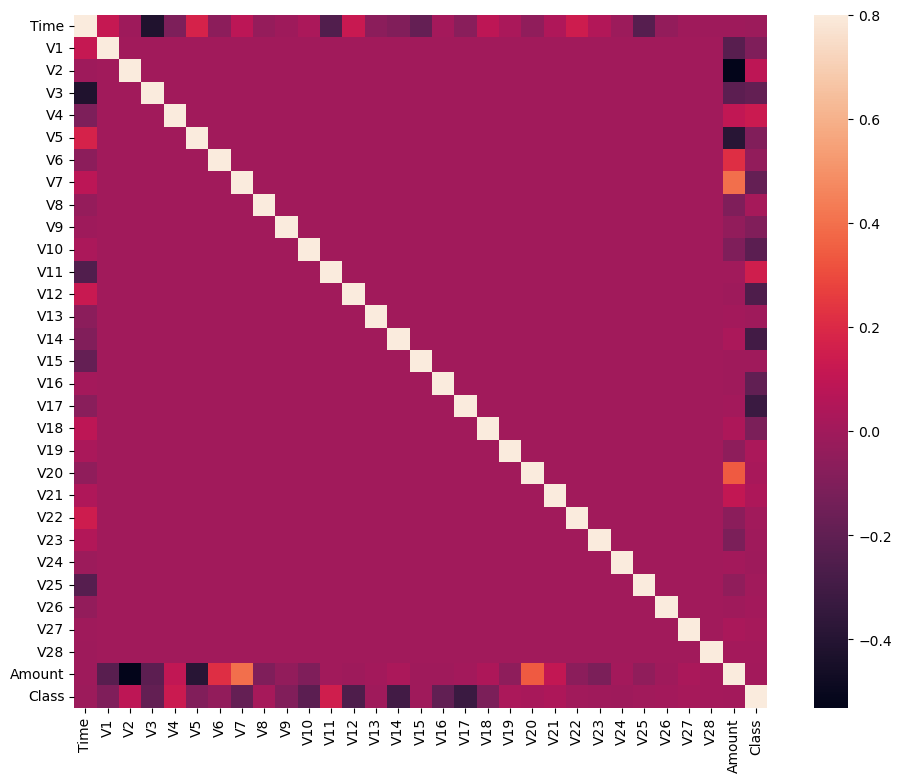

In [11]:
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()


in this we can see the most of the features do not correlate to other features but there are some features that either be positive aur negative correlation with each other.

<AxesSubplot:xlabel='Class', ylabel='count'>

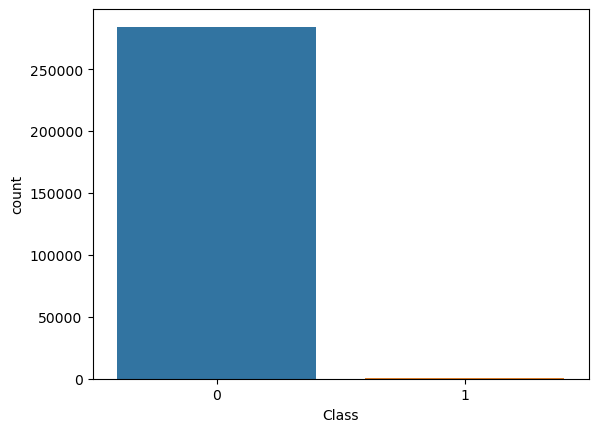

In [12]:
sns.countplot(x='Class',data=data)

## Step 4 developing a fraud detection model

### splitting the data in training and testing data.

In [14]:
X=data.drop(['Class'],axis=1)
Y=data['Class']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

## Logistic Regression

### initialize and fit into data

In [15]:
model=LogisticRegression()
model.fit(X_train,Y_train)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## Predicting the value for data

In [16]:
Y_pred=model.predict(X_test)

## Step 5 Evaluating the Model

In [17]:
confusion_matrix(Y_test,Y_pred)

array([[85282,    25],
       [   53,    83]], dtype=int64)

## F1 Score of the model

In [18]:
f1_score(Y_test,Y_pred)

0.680327868852459

## Accuracy of the Model

In [19]:
accuracy_score(Y_test,Y_pred)

0.9990871107053826

# Random Forest Classification

## Code: Separating the X and the Y values
dividing the data into inputs parameters and outputs value format

In [20]:
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
print(X.shape)
print(Y.shape)
#(its a numpy array with no columns)
xData = X.values
yData = Y.values

(284807, 30)
(284807,)



Training and Testing data we will dividing the dataset into 2 main groups one for training the model and other one for testing the model

In [21]:
#using scikit learn to split data into training and testing set
#split the data into training and testing sets
xTrain, xTest, yTrain, yTest = train_test_split(xData, yData, test_size = 0.2, random_state = 42)

## code : Building a Random Forest Model

In [24]:
#Building the Random Forest Classifier (RANDOM FOREST)
from sklearn.ensemble import RandomForestClassifier
# random forest model creation
rfc = RandomForestClassifier()
rfc.fit(xTrain, yTrain)
# predictions
yPred = rfc.predict(xTest)

In [25]:
# Evaluating the classifier
# printing every score of the classifier
# scoring in anything
from sklearn.metrics import classification_report, accuracy_score 
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix

In [26]:
n_outliers = len(fraud)
n_errors = (yPred != yTest).sum()
print("The model used is Random Forest classifier")

The model used is Random Forest classifier


# Accuracy of the model

In [27]:
acc = accuracy_score(yTest, yPred)
print("The accuracy is {}".format(acc))

The accuracy is 0.9995786664794073


# Precision

In [28]:
prec = precision_score(yTest, yPred)
print("The precision is {}".format(prec))

The precision is 0.9743589743589743


# Recall score

In [29]:
rec = recall_score(yTest, yPred)
print("The recall is {}".format(rec))

The recall is 0.7755102040816326


# F1 score

In [30]:
f1 = f1_score(yTest, yPred)
print("The F1-Score is {}".format(f1))

The F1-Score is 0.8636363636363635


In [31]:
MCC = matthews_corrcoef(yTest, yPred)
print("The Matthews correlation coefficient is{}".format(MCC))

The Matthews correlation coefficient is0.8690748763736589


# Visualizing the matrix

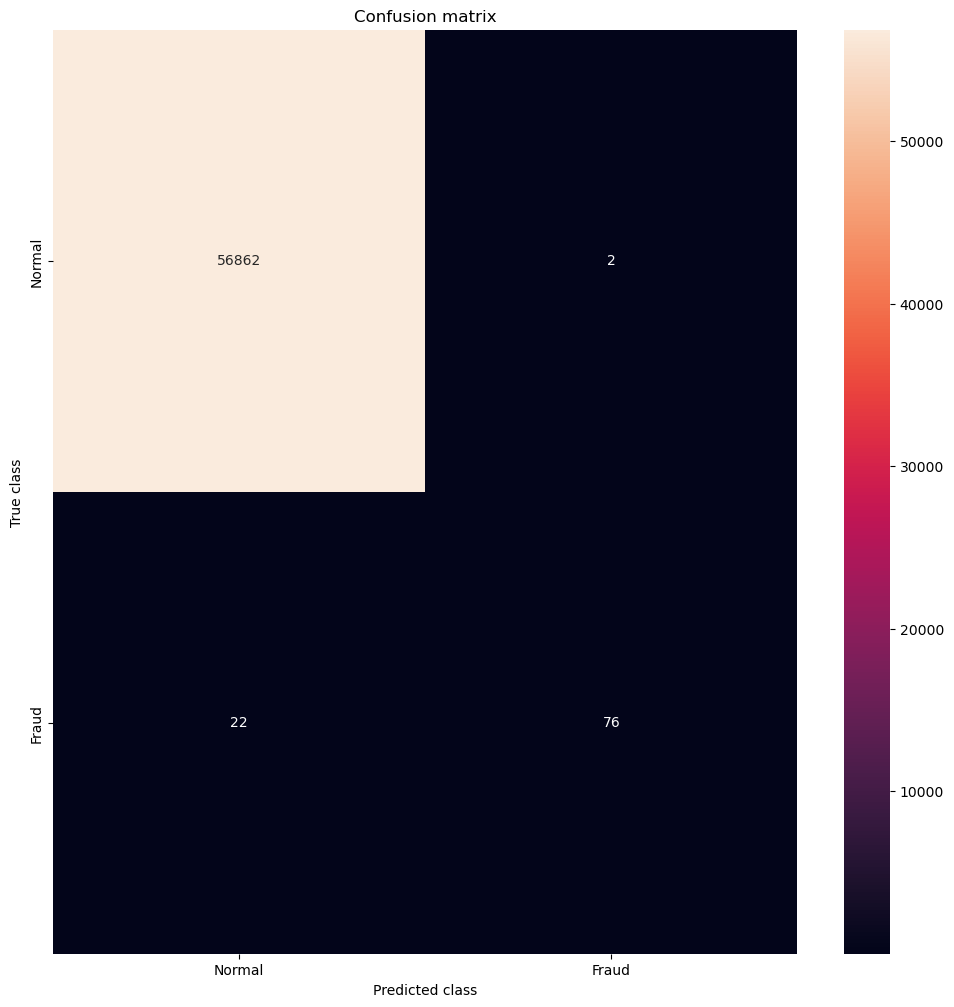

In [32]:
# printing the confusion matrix
LABELS = ['Normal', 'Fraud']
conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize =(12, 12))
sns.heatmap(conf_matrix, xticklabels = LABELS, 
            yticklabels = LABELS, annot = True, fmt ="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()